# Notebook 07: Inventory Optimization & Business Recommendations

## Objective

This notebook integrates demand forecasting, customer segmentation, and churn prediction results to generate inventory optimization insights and actionable business recommendations.

### Goals

- Analyze forecasted sales demand.
- Classify inventory stock status.
- Identify products requiring restocking.
- Generate business KPIs.
- Create inventory recommendations.
- Export final reports for the Streamlit dashboard.

### Input Files

- data/processed/retail_cleaned.csv
- data/processed/customer_segments.csv
- reports/forecast_results.csv
- reports/high_risk_customers.csv

### Output Files

- reports/inventory_summary.csv
- reports/inventory_recommendations.csv
- reports/business_recommendations.csv

In [24]:
# ============================================================
# Import Libraries
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [25]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"

REPORTS_DIR.mkdir(exist_ok=True)

print("Project Root :", PROJECT_ROOT)
print("Processed Data:", PROCESSED_DIR)
print("Reports:", REPORTS_DIR)

Project Root : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics
Processed Data: c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\data\processed
Reports: c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\reports


In [26]:
# ============================================================
# Validate Required Files
# ============================================================

required_files = [
    PROCESSED_DIR / "retail_cleaned.csv",
    PROCESSED_DIR / "customer_segments.csv",
    REPORTS_DIR / "forecast_results.csv",
    REPORTS_DIR / "high_risk_customers.csv",
]

for file in required_files:
    if not file.exists():
        raise FileNotFoundError(f"Missing file: {file}")

print("✅ All required datasets found.")

✅ All required datasets found.


In [27]:
# ============================================================
# Load Required Datasets
# ============================================================

retail_df = pd.read_csv(PROCESSED_DIR / "retail_cleaned.csv")
segments_df = pd.read_csv(PROCESSED_DIR / "customer_segments.csv")

forecast_df = pd.read_csv(REPORTS_DIR / "forecast_results.csv")
churn_df = pd.read_csv(REPORTS_DIR / "high_risk_customers.csv")

print("=" * 50)
print("Datasets Loaded Successfully")
print("=" * 50)

print(f"Retail Dataset          : {retail_df.shape}")
print(f"Customer Segments       : {segments_df.shape}")
print(f"Forecast Results        : {forecast_df.shape}")
print(f"High-Risk Customers     : {churn_df.shape}")

Datasets Loaded Successfully
Retail Dataset          : (779425, 22)
Customer Segments       : (5878, 3)
Forecast Results        : (142, 3)
High-Risk Customers     : (3414, 16)


In [28]:
# ============================================================
# Dataset Preview
# ============================================================

display(retail_df.head())

display(segments_df.head())

display(forecast_df.head())

display(churn_df.head())

,InvoiceID,StockCode,ProductDescription,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,InvoiceYear,...,MonthName,InvoiceWeek,InvoiceDay,DayName,InvoiceHour,IsWeekend,CustomerCountry,InvoiceMonthYear,BasketSize,BasketValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,...,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,...,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,...,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,...,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,...,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3


,CustomerID,Cluster,Segment
0,12346.0,2,Champions
1,12347.0,3,Loyal Customers
2,12348.0,3,Loyal Customers
3,12349.0,3,Loyal Customers
4,12350.0,1,At Risk Customers


,Date,ActualSales,PredictedSales
0,2011-07-21,30271.94,31001.486
1,2011-07-22,14628.88,23278.828
2,2011-07-23,0.00,4034.154
3,2011-07-24,26777.92,16193.429
4,2011-07-25,19676.55,33232.863


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts,UniqueCountries,FirstPurchase,LastPurchase,CustomerLifetimeDays,ActiveMonths,RevenuePerMonth,AvgQuantityPerOrder,Churn,PredictedChurn
0,12350.0,310,1,334.40,197,19.670588,17,1,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.0,334.40,197.0,1,1
1,12351.0,375,1,300.93,261,14.330000,21,1,2010-11-29 15:23:00,2010-11-29 15:23:00,0,1.0,300.93,261.0,1,1
2,12353.0,204,2,406.76,212,16.948333,23,1,2010-10-27 12:44:00,2011-05-19 17:47:00,204,6.8,59.82,106.0,1,1
3,12354.0,232,1,1079.40,530,18.610345,58,1,2011-04-21 13:11:00,2011-04-21 13:11:00,0,1.0,1079.40,530.0,1,1
4,12355.0,214,2,947.61,543,27.074571,35,1,2010-05-21 11:59:00,2011-05-09 13:49:00,353,11.8,80.31,271.5,1,1


In [29]:
# ============================================================
# Inventory Demand Analysis
# ============================================================

inventory_summary = (
    retail_df
    .groupby(["StockCode", "ProductDescription"], as_index=False)
    .agg(
        TotalQuantity=("Quantity", "sum"),
        TotalRevenue=("TotalAmount", "sum"),
        TotalOrders=("InvoiceID", "nunique")
    )
)

inventory_summary = inventory_summary.sort_values(
    by="TotalQuantity",
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("Top 10 Products by Quantity Sold")
print("=" * 60)

display(inventory_summary.head(10))

Top 10 Products by Quantity Sold


,StockCode,ProductDescription,TotalQuantity,TotalRevenue,TotalOrders
0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,105185,24098.03,920
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01,4888
2,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
3,84879,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86,2652
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195
5,85099B,JUMBO BAG RED RETROSPOT,74224,134307.44,2612
6,17003,BROCADE RING PURSE,70082,14640.96,387
7,21977,PACK OF 60 PINK PAISLEY CAKE CASES,54592,26407.35,1578
8,84991,60 TEATIME FAIRY CAKE CASES,52828,25785.92,1765
9,21212,PACK OF 72 RETRO SPOT CAKE CASES,45129,21838.23,1160


In [30]:
# ============================================================
# Inventory Summary Statistics
# ============================================================

display(inventory_summary.describe())

,TotalQuantity,TotalRevenue,TotalOrders
count,5315.000000,5315.000000,5315.000000
mean,1978.165945,3269.013033,144.659831
std,5005.829541,9237.142488,246.953843
min,1.000000,0.017000,1.000000
25%,88.500000,201.965000,14.000000
50%,507.000000,850.200000,55.000000
75%,1818.500000,2825.880000,169.000000
max,105185.000000,277656.250000,4888.000000


In [31]:
# ============================================================
# Inventory Classification
# ============================================================

high_threshold = inventory_summary["TotalQuantity"].quantile(0.75)
low_threshold = inventory_summary["TotalQuantity"].quantile(0.25)

inventory_summary["InventoryStatus"] = np.select(
    [
        inventory_summary["TotalQuantity"] >= high_threshold,
        inventory_summary["TotalQuantity"] <= low_threshold
    ],
    [
        "High Demand",
        "Low Demand"
    ],
    default="Medium Demand"
)

print(inventory_summary["InventoryStatus"].value_counts())

display(inventory_summary.head())

InventoryStatus
Medium Demand    2657
High Demand      1329
Low Demand       1329
Name: count, dtype: int64


,StockCode,ProductDescription,TotalQuantity,TotalRevenue,TotalOrders,InventoryStatus
0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,105185,24098.03,920,High Demand
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01,4888,High Demand
2,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,High Demand
3,84879,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86,2652,High Demand
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195,High Demand


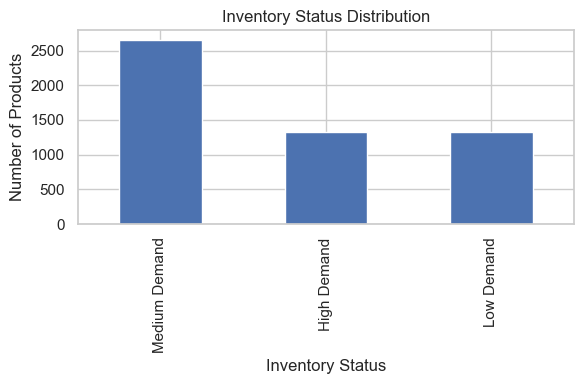

In [32]:
# ============================================================
# Inventory Status Distribution
# ============================================================

plt.figure(figsize=(6,4))

inventory_summary["InventoryStatus"].value_counts().plot(kind="bar")

plt.title("Inventory Status Distribution")
plt.xlabel("Inventory Status")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# Inventory Recommendations
# ============================================================

inventory_summary["Recommendation"] = np.select(
    [
        inventory_summary["InventoryStatus"] == "High Demand",
        inventory_summary["InventoryStatus"] == "Medium Demand",
        inventory_summary["InventoryStatus"] == "Low Demand"
    ],
    [
        "Increase Stock",
        "Maintain Stock",
        "Reduce Stock"
    ],
    default="Review"
)

display(inventory_summary.head())

print("\nRecommendation Distribution\n")
print(inventory_summary["Recommendation"].value_counts())

,StockCode,ProductDescription,TotalQuantity,TotalRevenue,TotalOrders,InventoryStatus,Recommendation
0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,105185,24098.03,920,High Demand,Increase Stock
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01,4888,High Demand,Increase Stock
2,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,High Demand,Increase Stock
3,84879,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86,2652,High Demand,Increase Stock
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195,High Demand,Increase Stock



Recommendation Distribution

Recommendation
Maintain Stock    2657
Increase Stock    1329
Reduce Stock      1329
Name: count, dtype: int64


In [34]:
# ============================================================
# Business KPIs
# ============================================================

total_products = inventory_summary.shape[0]
high_demand = (inventory_summary["InventoryStatus"] == "High Demand").sum()
medium_demand = (inventory_summary["InventoryStatus"] == "Medium Demand").sum()
low_demand = (inventory_summary["InventoryStatus"] == "Low Demand").sum()

forecasted_sales = forecast_df["PredictedSales"].sum()

high_risk_customers = churn_df.shape[0]
total_customers = segments_df.shape[0]

print("=" * 60)
print("BUSINESS KPI SUMMARY")
print("=" * 60)

print(f"Total Products              : {total_products}")
print(f"High Demand Products        : {high_demand}")
print(f"Medium Demand Products      : {medium_demand}")
print(f"Low Demand Products         : {low_demand}")

print()

print(f"Forecasted Sales            : {forecasted_sales:,.2f}")

print()

print(f"Total Customers             : {total_customers}")
print(f"High-Risk Customers         : {high_risk_customers}")

print(f"Customer Churn Rate         : {(high_risk_customers/total_customers)*100:.2f}%")

BUSINESS KPI SUMMARY
Total Products              : 5315
High Demand Products        : 1329
Medium Demand Products      : 2657
Low Demand Products         : 1329

Forecasted Sales            : 4,461,221.47

Total Customers             : 5878
High-Risk Customers         : 3414
Customer Churn Rate         : 58.08%


In [35]:
# ============================================================
# Business Recommendations
# ============================================================

business_recommendations = pd.DataFrame({
    "Category": [
        "Inventory",
        "Inventory",
        "Sales Forecasting",
        "Customer Retention",
        "Marketing"
    ],
    "Recommendation": [
        "Increase inventory for high-demand products.",
        "Reduce inventory for low-demand products to minimize holding costs.",
        "Use demand forecasts for procurement and replenishment planning.",
        "Target high-risk customers with personalized retention campaigns.",
        "Offer promotions to medium-demand products to increase sales."
    ]
})

display(business_recommendations)

,Category,Recommendation
0,Inventory,Increase inventory for high-demand products.
1,Inventory,Reduce inventory for low-demand products to mi...
2,Sales Forecasting,Use demand forecasts for procurement and reple...
3,Customer Retention,Target high-risk customers with personalized r...
4,Marketing,Offer promotions to medium-demand products to ...


In [36]:
# ============================================================
# Save Reports
# ============================================================

inventory_summary.to_csv(
    REPORTS_DIR / "inventory_summary.csv",
    index=False
)

inventory_summary[
    [
        "StockCode",
        "ProductDescription",
        "InventoryStatus",
        "Recommendation"
    ]
].to_csv(
    REPORTS_DIR / "inventory_recommendations.csv",
    index=False
)

business_recommendations.to_csv(
    REPORTS_DIR / "business_recommendations.csv",
    index=False
)

print("=" * 60)
print("Reports Saved Successfully")
print("=" * 60)

print(REPORTS_DIR / "inventory_summary.csv")
print(REPORTS_DIR / "inventory_recommendations.csv")
print(REPORTS_DIR / "business_recommendations.csv")

Reports Saved Successfully
c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\reports\inventory_summary.csv
c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\reports\inventory_recommendations.csv
c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\reports\business_recommendations.csv


In [37]:
# ============================================================
# Notebook Summary
# ============================================================

print("=" * 70)
print("NOTEBOOK 07 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"Products Analysed           : {total_products}")
print(f"High Demand Products        : {high_demand}")
print(f"Medium Demand Products      : {medium_demand}")
print(f"Low Demand Products         : {low_demand}")

print()

print(f"Forecasted Sales            : {forecasted_sales:,.2f}")

print()

print(f"High-Risk Customers         : {high_risk_customers}")
print(f"Customer Churn Rate         : {(high_risk_customers/total_customers)*100:.2f}%")

print()

print("Generated Reports:")
print("✓ inventory_summary.csv")
print("✓ inventory_recommendations.csv")
print("✓ business_recommendations.csv")

print("\nNotebook 07 Finished Successfully!")

NOTEBOOK 07 COMPLETED SUCCESSFULLY
Products Analysed           : 5315
High Demand Products        : 1329
Medium Demand Products      : 2657
Low Demand Products         : 1329

Forecasted Sales            : 4,461,221.47

High-Risk Customers         : 3414
Customer Churn Rate         : 58.08%

Generated Reports:
✓ inventory_summary.csv
✓ inventory_recommendations.csv
✓ business_recommendations.csv

Notebook 07 Finished Successfully!
